# Retrieval Results Analysis

This notebook uses `tasting_analysis.py` workflows to:

1. Run CCF robustness checks between observed combined spectra and retrieval scaled model flux.
2. Compute chemistry diagnostics (C/O and `12CO/13CO`) with 1-sigma and 3-sigma intervals.

## Retrieval: 889297_N200_ev0.5

Run cells in order from top to bottom.

In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tasting_analysis import run_ccf_workflow, run_chemistry_workflow

In [ ]:


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
workpath = Path('/data2/peng')
retrieval_id = '889297_N200_ev0.5'
night = '2022-12-31'

print('workpath:', workpath)
print('retrieval_id:', retrieval_id)
print('night:', night)
print('retrieval exists:', (workpath / 'retrievals' / retrieval_id).exists())

workpath: /data2/peng
retrieval_id: 889297_N200_ev0.5
night: 2022-12-31
retrieval exists: True


Combined spectra file: /data2/peng/2022-12-31/extracted_spectra_combined_sigmaclipper.npy
Valid pixels used: 26773
Peak SNR = 30.18 at RV = 3.0 km/s
Null peak SNR mean±std = 7.17 ± 9.74
Detection z-score (vs shuffled null) = 2.36


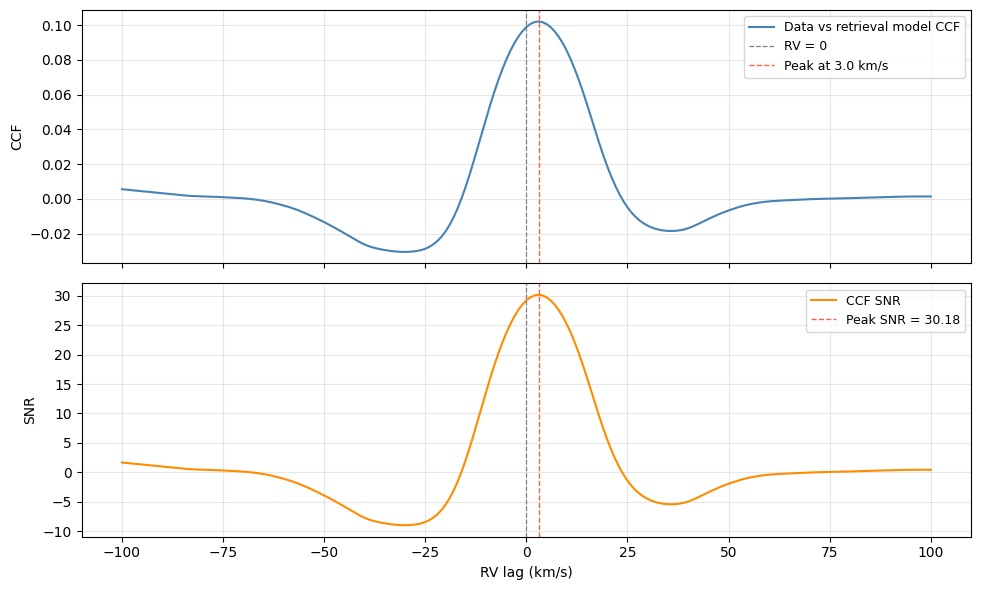

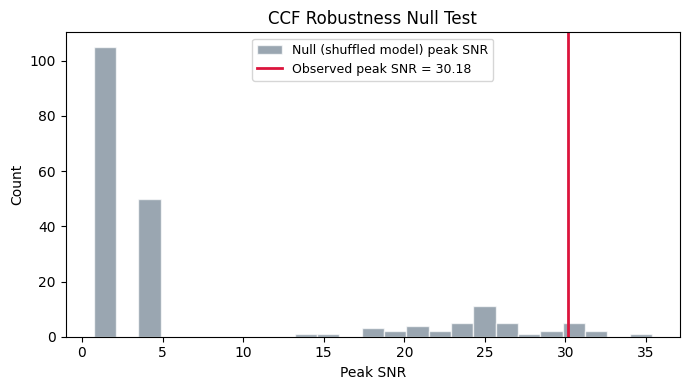

In [2]:
# ------------------------------------------------------------------
# 1) CCF robustness workflow
# ------------------------------------------------------------------
ccf_out = run_ccf_workflow(
    workpath=workpath,
    retrieval_id=retrieval_id,
    night=night,
    rvlag=np.arange(-100, 101, 1),
    clean_grids=((0, 50), (150, 200)),
    n_shuffle=200,
    random_seed=42,
 )

print('Combined spectra file:', ccf_out['combined_path'])
print('Valid pixels used:', ccf_out['valid_pixels'])
print(f"Peak SNR = {ccf_out['peak_snr']:.2f} at RV = {ccf_out['peak_rv']:.1f} km/s")
print(f"Null peak SNR mean±std = {ccf_out['null_mu']:.2f} ± {ccf_out['null_sigma']:.2f}")
print(f"Detection z-score (vs shuffled null) = {ccf_out['z_score']:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(ccf_out['rvlag'], ccf_out['ccf'], color='steelblue', lw=1.5, label='Data vs retrieval model CCF')
axes[0].axvline(0, color='gray', ls='--', lw=0.9, label='RV = 0')
axes[0].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak at {ccf_out['peak_rv']:.1f} km/s")
axes[0].set_ylabel('CCF')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].plot(ccf_out['rvlag'], ccf_out['ccf_snr'], color='darkorange', lw=1.5, label='CCF SNR')
axes[1].axvline(0, color='gray', ls='--', lw=0.9)
axes[1].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak SNR = {ccf_out['peak_snr']:.2f}")
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ccf_out['null_peaks'], bins=25, alpha=0.7, color='slategray', edgecolor='white',
         label='Null (shuffled model) peak SNR')
plt.axvline(ccf_out['peak_snr'], color='crimson', lw=2,
            label=f"Observed peak SNR = {ccf_out['peak_snr']:.2f}")
plt.xlabel('Peak SNR')
plt.ylabel('Count')
plt.title('CCF Robustness Null Test')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Posterior shape: (2237, 12)
Posterior columns: ['rv', 'vsini', 'log_g', 'T0', 'T1', 'T2', 'T3', 'T4', 'log_H2O', 'log_12CO', 'log_13CO', 'log_CH4']


,parameter,p0.135,p16,p50,p84,p99.865,minus_1sigma,plus_1sigma,minus_3sigma,plus_3sigma
0,C/O (from posterior chemistry),0.001608,0.001825,0.001934,0.002052,0.002316,0.000109,0.000118,0.000326,0.000382
1,12CO/13CO,0.000003,0.000197,0.000499,0.001144,0.003936,0.000302,0.000645,0.000496,0.003437



Text summary:
C/O (from posterior chemistry): median=0.001934, 1σ=[-0.000109, +0.000118], 3σ=[-0.000326, +0.000382]
12CO/13CO: median=0.0004989, 1σ=[-0.000302, +0.000645], 3σ=[-0.000496, +0.00344]


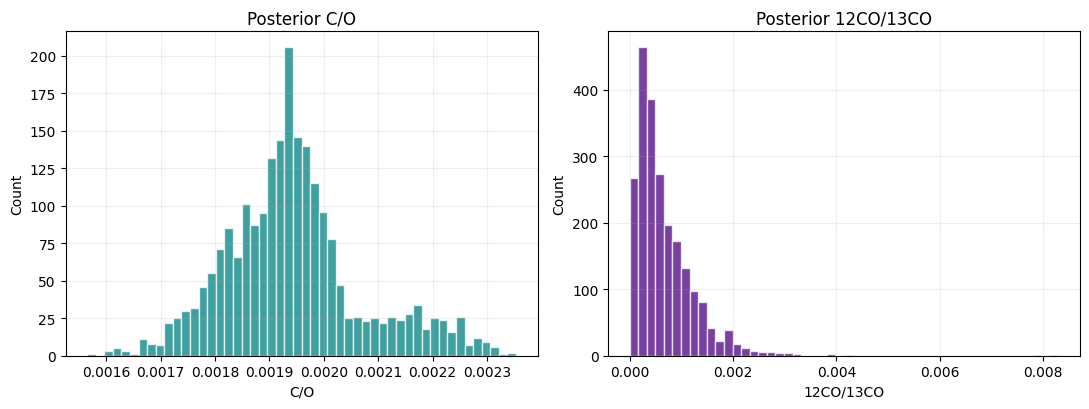

In [3]:
# ------------------------------------------------------------------
# 2) Chemistry diagnostics workflow
# ------------------------------------------------------------------
chem_out = run_chemistry_workflow(workpath=workpath, retrieval_id=retrieval_id)

print('Posterior shape:', chem_out['posterior'].shape)
print('Posterior columns:', chem_out['columns'])
display(chem_out['summary'])

print('\nText summary:')
for _, row in chem_out['summary'].iterrows():
    print(
        f"{row['parameter']}: median={row['p50']:.4g}, "
        f"1σ=[-{row['minus_1sigma']:.3g}, +{row['plus_1sigma']:.3g}], "
        f"3σ=[-{row['minus_3sigma']:.3g}, +{row['plus_3sigma']:.3g}]"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(chem_out['co_ratio_samples'][np.isfinite(chem_out['co_ratio_samples'])],
             bins=50, color='teal', alpha=0.75, edgecolor='white')
axes[0].set_title('Posterior C/O')
axes[0].set_xlabel('C/O')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.2)

axes[1].hist(chem_out['c12_c13_samples'][np.isfinite(chem_out['c12_c13_samples'])],
             bins=50, color='indigo', alpha=0.75, edgecolor='white')
axes[1].set_title('Posterior 12CO/13CO')
axes[1].set_xlabel('12CO/13CO')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 772437_N200_ev0.5

Norm: No

Scaling parameter: Yes

In [5]:
workpath = Path('/data2/peng')
retrieval_id = '772437_N200_ev0.5'
night = '2022-12-31'

print('workpath:', workpath)
print('retrieval_id:', retrieval_id)
print('night:', night)
print('retrieval exists:', (workpath / 'retrievals' / retrieval_id).exists())

workpath: /data2/peng
retrieval_id: 772437_N200_ev0.5
night: 2022-12-31
retrieval exists: True


Combined spectra file: /data2/peng/2022-12-31/extracted_spectra_combined_sigmaclipper.npy
Valid pixels used: 26773
Peak SNR = 6.81 at RV = -1.0 km/s
Null peak SNR mean±std = 7.37 ± 9.32
Detection z-score (vs shuffled null) = -0.06


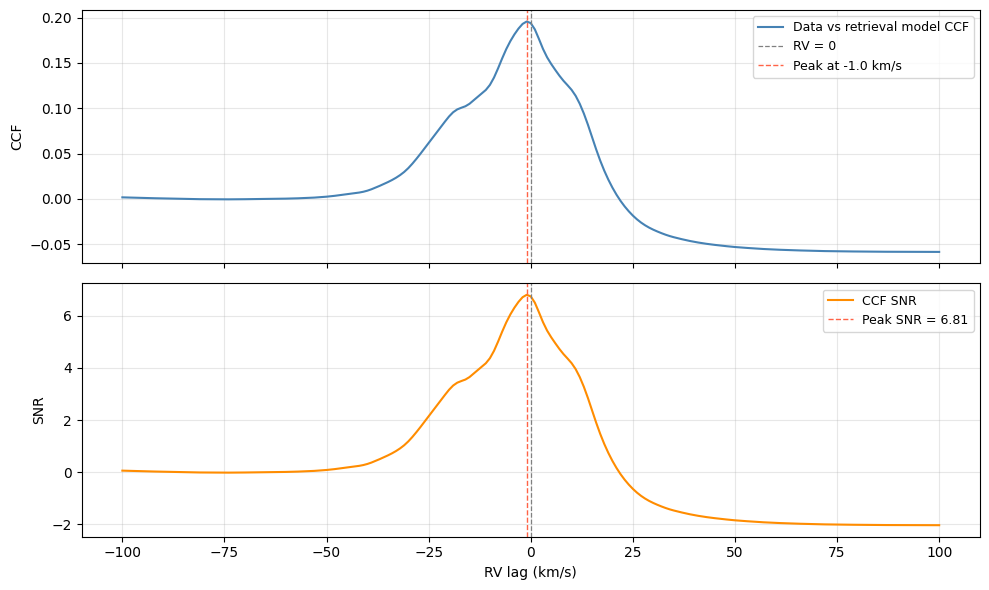

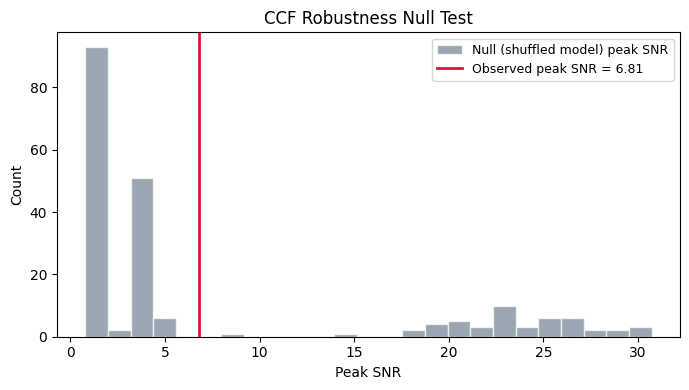

In [6]:
# ------------------------------------------------------------------
# 1) CCF robustness workflow
# ------------------------------------------------------------------
ccf_out = run_ccf_workflow(
    workpath=workpath,
    retrieval_id=retrieval_id,
    night=night,
    rvlag=np.arange(-100, 101, 1),
    clean_grids=((0, 50), (150, 200)),
    n_shuffle=200,
    random_seed=42,
 )

print('Combined spectra file:', ccf_out['combined_path'])
print('Valid pixels used:', ccf_out['valid_pixels'])
print(f"Peak SNR = {ccf_out['peak_snr']:.2f} at RV = {ccf_out['peak_rv']:.1f} km/s")
print(f"Null peak SNR mean±std = {ccf_out['null_mu']:.2f} ± {ccf_out['null_sigma']:.2f}")
print(f"Detection z-score (vs shuffled null) = {ccf_out['z_score']:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(ccf_out['rvlag'], ccf_out['ccf'], color='steelblue', lw=1.5, label='Data vs retrieval model CCF')
axes[0].axvline(0, color='gray', ls='--', lw=0.9, label='RV = 0')
axes[0].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak at {ccf_out['peak_rv']:.1f} km/s")
axes[0].set_ylabel('CCF')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].plot(ccf_out['rvlag'], ccf_out['ccf_snr'], color='darkorange', lw=1.5, label='CCF SNR')
axes[1].axvline(0, color='gray', ls='--', lw=0.9)
axes[1].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak SNR = {ccf_out['peak_snr']:.2f}")
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ccf_out['null_peaks'], bins=25, alpha=0.7, color='slategray', edgecolor='white',
         label='Null (shuffled model) peak SNR')
plt.axvline(ccf_out['peak_snr'], color='crimson', lw=2,
            label=f"Observed peak SNR = {ccf_out['peak_snr']:.2f}")
plt.xlabel('Peak SNR')
plt.ylabel('Count')
plt.title('CCF Robustness Null Test')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Posterior shape: (1643, 12)
Posterior columns: ['rv', 'vsini', 'log_g', 'T0', 'T1', 'T2', 'T3', 'T4', 'log_H2O', 'log_12CO', 'log_13CO', 'log_CH4']


,parameter,p0.135,p16,p50,p84,p99.865,minus_1sigma,plus_1sigma,minus_3sigma,plus_3sigma
0,C/O (from posterior chemistry),0.914501,0.921794,0.925739,0.930011,0.936853,0.003945,0.004271,0.011238,0.011114
1,12CO/13CO,0.783791,0.896428,0.949311,0.990258,1.047763,0.052883,0.040947,0.165520,0.098452



Text summary:
C/O (from posterior chemistry): median=0.9257, 1σ=[-0.00395, +0.00427], 3σ=[-0.0112, +0.0111]
12CO/13CO: median=0.9493, 1σ=[-0.0529, +0.0409], 3σ=[-0.166, +0.0985]


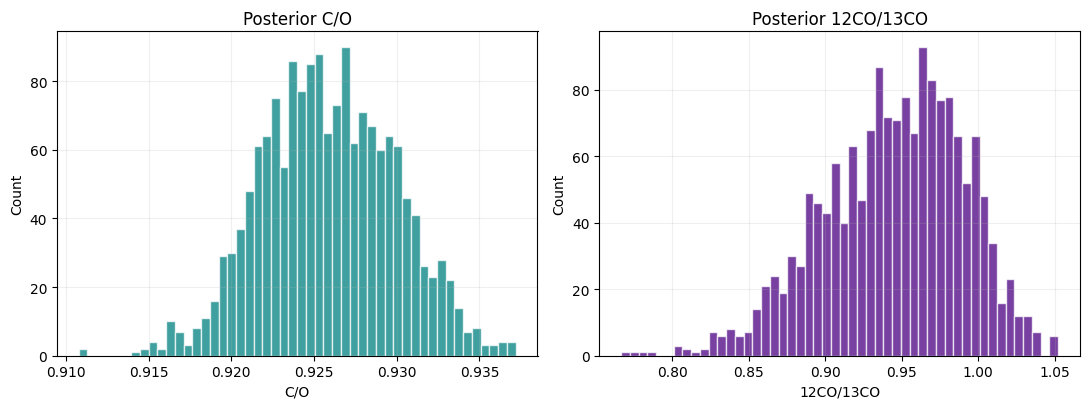

In [7]:
# ------------------------------------------------------------------
# 2) Chemistry diagnostics workflow
# ------------------------------------------------------------------
chem_out = run_chemistry_workflow(workpath=workpath, retrieval_id=retrieval_id)

print('Posterior shape:', chem_out['posterior'].shape)
print('Posterior columns:', chem_out['columns'])
display(chem_out['summary'])

print('\nText summary:')
for _, row in chem_out['summary'].iterrows():
    print(
        f"{row['parameter']}: median={row['p50']:.4g}, "
        f"1σ=[-{row['minus_1sigma']:.3g}, +{row['plus_1sigma']:.3g}], "
        f"3σ=[-{row['minus_3sigma']:.3g}, +{row['plus_3sigma']:.3g}]"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(chem_out['co_ratio_samples'][np.isfinite(chem_out['co_ratio_samples'])],
             bins=50, color='teal', alpha=0.75, edgecolor='white')
axes[0].set_title('Posterior C/O')
axes[0].set_xlabel('C/O')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.2)

axes[1].hist(chem_out['c12_c13_samples'][np.isfinite(chem_out['c12_c13_samples'])],
             bins=50, color='indigo', alpha=0.75, edgecolor='white')
axes[1].set_title('Posterior 12CO/13CO')
axes[1].set_xlabel('12CO/13CO')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 1331743_N200_ev0.5

Norm: Savgol

Scaling parameter: No

In [12]:
workpath = Path('/data2/peng')
retrieval_id = '1331743_N200_ev0.5'
night = '2022-12-31'

print('workpath:', workpath)
print('retrieval_id:', retrieval_id)
print('night:', night)
print('retrieval exists:', (workpath / 'retrievals' / retrieval_id).exists())

workpath: /data2/peng
retrieval_id: 1331743_N200_ev0.5
night: 2022-12-31
retrieval exists: True


Combined spectra file: /data2/peng/2022-12-31/extracted_spectra_combined_sigmaclipper.npy
Valid pixels used: 26773
Peak SNR = 4.89 at RV = 7.0 km/s
Null peak SNR mean±std = 7.50 ± 9.65
Detection z-score (vs shuffled null) = -0.27


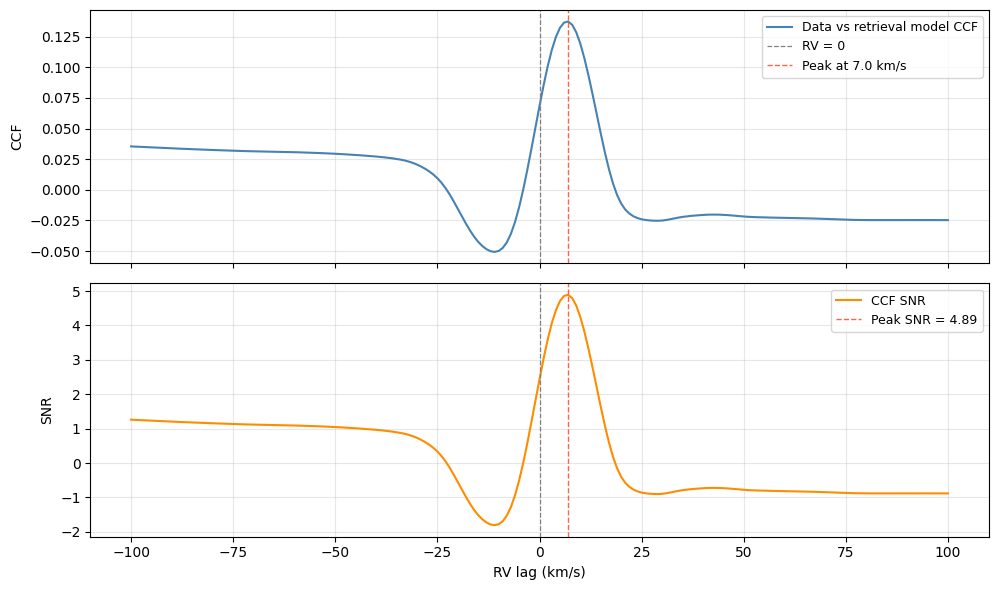

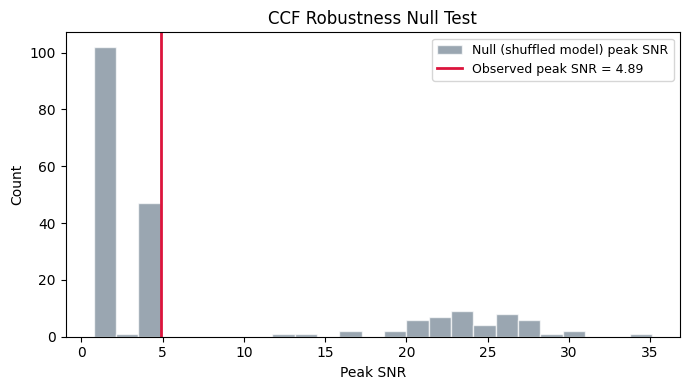

In [13]:
# ------------------------------------------------------------------
# 1) CCF robustness workflow
# ------------------------------------------------------------------
ccf_out = run_ccf_workflow(
    workpath=workpath,
    retrieval_id=retrieval_id,
    night=night,
    rvlag=np.arange(-100, 101, 1),
    clean_grids=((0, 50), (150, 200)),
    n_shuffle=200,
    random_seed=42,
 )

print('Combined spectra file:', ccf_out['combined_path'])
print('Valid pixels used:', ccf_out['valid_pixels'])
print(f"Peak SNR = {ccf_out['peak_snr']:.2f} at RV = {ccf_out['peak_rv']:.1f} km/s")
print(f"Null peak SNR mean±std = {ccf_out['null_mu']:.2f} ± {ccf_out['null_sigma']:.2f}")
print(f"Detection z-score (vs shuffled null) = {ccf_out['z_score']:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(ccf_out['rvlag'], ccf_out['ccf'], color='steelblue', lw=1.5, label='Data vs retrieval model CCF')
axes[0].axvline(0, color='gray', ls='--', lw=0.9, label='RV = 0')
axes[0].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak at {ccf_out['peak_rv']:.1f} km/s")
axes[0].set_ylabel('CCF')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].plot(ccf_out['rvlag'], ccf_out['ccf_snr'], color='darkorange', lw=1.5, label='CCF SNR')
axes[1].axvline(0, color='gray', ls='--', lw=0.9)
axes[1].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak SNR = {ccf_out['peak_snr']:.2f}")
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ccf_out['null_peaks'], bins=25, alpha=0.7, color='slategray', edgecolor='white',
         label='Null (shuffled model) peak SNR')
plt.axvline(ccf_out['peak_snr'], color='crimson', lw=2,
            label=f"Observed peak SNR = {ccf_out['peak_snr']:.2f}")
plt.xlabel('Peak SNR')
plt.ylabel('Count')
plt.title('CCF Robustness Null Test')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Posterior shape: (1562, 12)
Posterior columns: ['rv', 'vsini', 'log_g', 'T0', 'T1', 'T2', 'T3', 'T4', 'log_H2O', 'log_12CO', 'log_13CO', 'log_CH4']


,parameter,p0.135,p16,p50,p84,p99.865,minus_1sigma,plus_1sigma,minus_3sigma,plus_3sigma
0,C/O (from posterior chemistry),2.388781e-08,4.934805e-07,0.000003,0.000014,0.000235,0.000002,0.000011,0.000003,0.000232
1,12CO/13CO,6.013729e-05,3.101970e-02,1.243004,53.556140,58328.092749,1.211984,52.313136,1.242944,58326.849745



Text summary:
C/O (from posterior chemistry): median=2.538e-06, 1σ=[-2.04e-06, +1.13e-05], 3σ=[-2.51e-06, +0.000232]
12CO/13CO: median=1.243, 1σ=[-1.21, +52.3], 3σ=[-1.24, +5.83e+04]


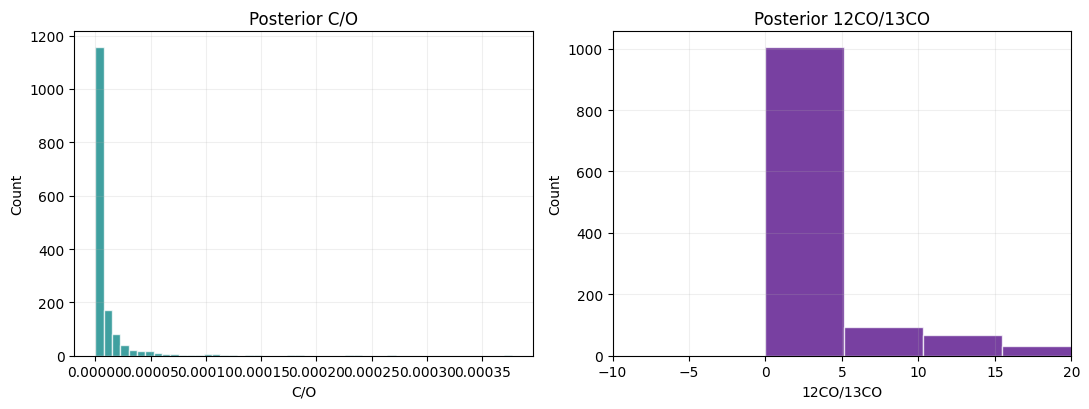

In [19]:
# ------------------------------------------------------------------
# 2) Chemistry diagnostics workflow
# ------------------------------------------------------------------
chem_out = run_chemistry_workflow(workpath=workpath, retrieval_id=retrieval_id)

print('Posterior shape:', chem_out['posterior'].shape)
print('Posterior columns:', chem_out['columns'])
display(chem_out['summary'])

print('\nText summary:')
for _, row in chem_out['summary'].iterrows():
    print(
        f"{row['parameter']}: median={row['p50']:.4g}, "
        f"1σ=[-{row['minus_1sigma']:.3g}, +{row['plus_1sigma']:.3g}], "
        f"3σ=[-{row['minus_3sigma']:.3g}, +{row['plus_3sigma']:.3g}]"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(chem_out['co_ratio_samples'][np.isfinite(chem_out['co_ratio_samples'])],
             bins=50, color='teal', alpha=0.75, edgecolor='white')
axes[0].set_title('Posterior C/O')
axes[0].set_xlabel('C/O')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.2)

axes[1].hist(chem_out['c12_c13_samples'][np.isfinite(chem_out['c12_c13_samples'])],
             bins=50000, color='indigo', alpha=0.75, edgecolor='white')
axes[1].set_xlim(-10,20)

axes[1].set_title('Posterior 12CO/13CO')
axes[1].set_xlabel('12CO/13CO')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 1335073_N200_ev0.5

Norm: Median 

Scaling parameter: No

In [4]:
workpath = Path('/data2/peng')
retrieval_id = '1335073_N200_ev0.5'
night = '2022-12-31'

print('workpath:', workpath)
print('retrieval_id:', retrieval_id)
print('night:', night)
print('retrieval exists:', (workpath / 'retrievals' / retrieval_id).exists())

workpath: /data2/peng
retrieval_id: 1335073_N200_ev0.5
night: 2022-12-31
retrieval exists: True


Combined spectra file: /data2/peng/2022-12-31/extracted_spectra_combined_sigmaclipper.npy
Valid pixels used: 26773
Peak SNR = 4.40 at RV = 3.0 km/s
Null peak SNR mean±std = 7.43 ± 9.87
Detection z-score (vs shuffled null) = -0.31


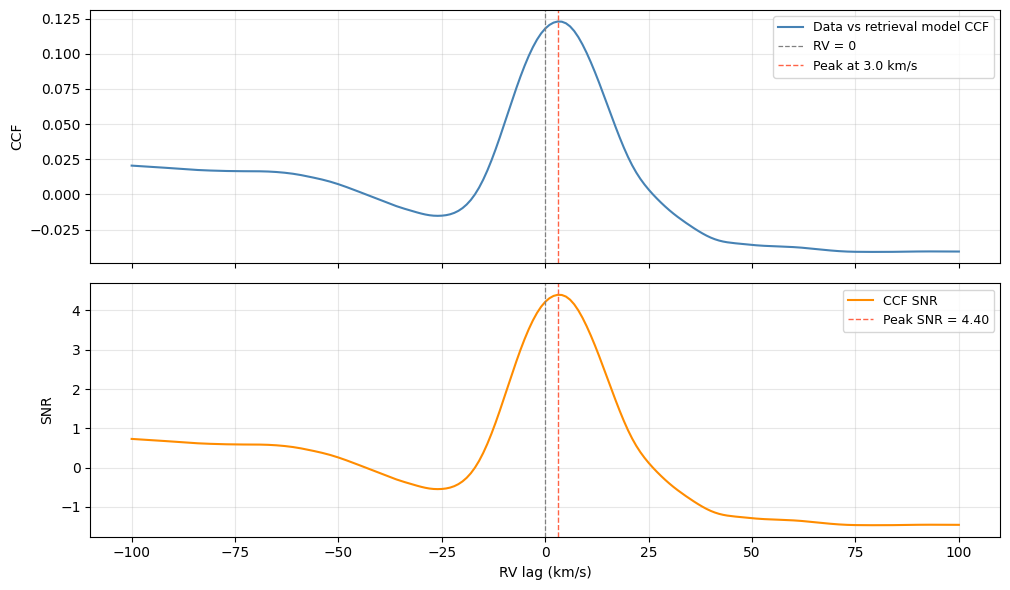

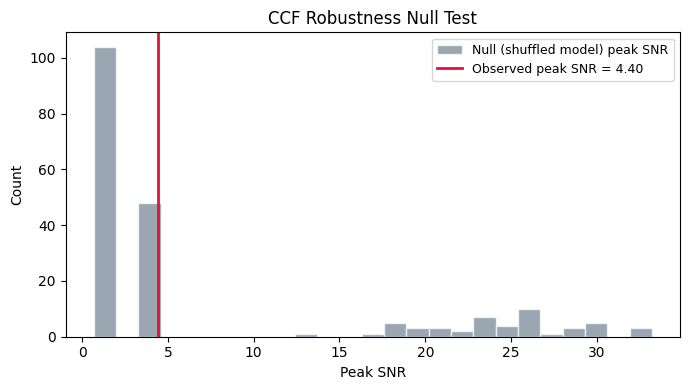

In [5]:
# ------------------------------------------------------------------
# 1) CCF robustness workflow
# ------------------------------------------------------------------
ccf_out = run_ccf_workflow(
    workpath=workpath,
    retrieval_id=retrieval_id,
    night=night,
    rvlag=np.arange(-100, 101, 1),
    clean_grids=((0, 50), (150, 200)),
    n_shuffle=200,
    random_seed=42,
 )

print('Combined spectra file:', ccf_out['combined_path'])
print('Valid pixels used:', ccf_out['valid_pixels'])
print(f"Peak SNR = {ccf_out['peak_snr']:.2f} at RV = {ccf_out['peak_rv']:.1f} km/s")
print(f"Null peak SNR mean±std = {ccf_out['null_mu']:.2f} ± {ccf_out['null_sigma']:.2f}")
print(f"Detection z-score (vs shuffled null) = {ccf_out['z_score']:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(ccf_out['rvlag'], ccf_out['ccf'], color='steelblue', lw=1.5, label='Data vs retrieval model CCF')
axes[0].axvline(0, color='gray', ls='--', lw=0.9, label='RV = 0')
axes[0].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak at {ccf_out['peak_rv']:.1f} km/s")
axes[0].set_ylabel('CCF')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].plot(ccf_out['rvlag'], ccf_out['ccf_snr'], color='darkorange', lw=1.5, label='CCF SNR')
axes[1].axvline(0, color='gray', ls='--', lw=0.9)
axes[1].axvline(ccf_out['peak_rv'], color='tomato', ls='--', lw=1.0,
                label=f"Peak SNR = {ccf_out['peak_snr']:.2f}")
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ccf_out['null_peaks'], bins=25, alpha=0.7, color='slategray', edgecolor='white',
         label='Null (shuffled model) peak SNR')
plt.axvline(ccf_out['peak_snr'], color='crimson', lw=2,
            label=f"Observed peak SNR = {ccf_out['peak_snr']:.2f}")
plt.xlabel('Peak SNR')
plt.ylabel('Count')
plt.title('CCF Robustness Null Test')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Posterior shape: (2613, 12)
Posterior columns: ['rv', 'vsini', 'log_g', 'T0', 'T1', 'T2', 'T3', 'T4', 'log_H2O', 'log_12CO', 'log_13CO', 'log_CH4']


,parameter,p0.135,p16,p50,p84,p99.865,minus_1sigma,plus_1sigma,minus_3sigma,plus_3sigma
0,C/O (from posterior chemistry),0.019152,0.020303,0.021109,0.021635,0.022385,0.000806,0.000525,0.001957,0.001275
1,12CO/13CO,0.000007,0.000058,0.000113,0.000198,0.000448,0.000056,0.000084,0.000106,0.000335



Text summary:
C/O (from posterior chemistry): median=0.02111, 1σ=[-0.000806, +0.000525], 3σ=[-0.00196, +0.00128]
12CO/13CO: median=0.0001133, 1σ=[-5.57e-05, +8.44e-05], 3σ=[-0.000106, +0.000335]


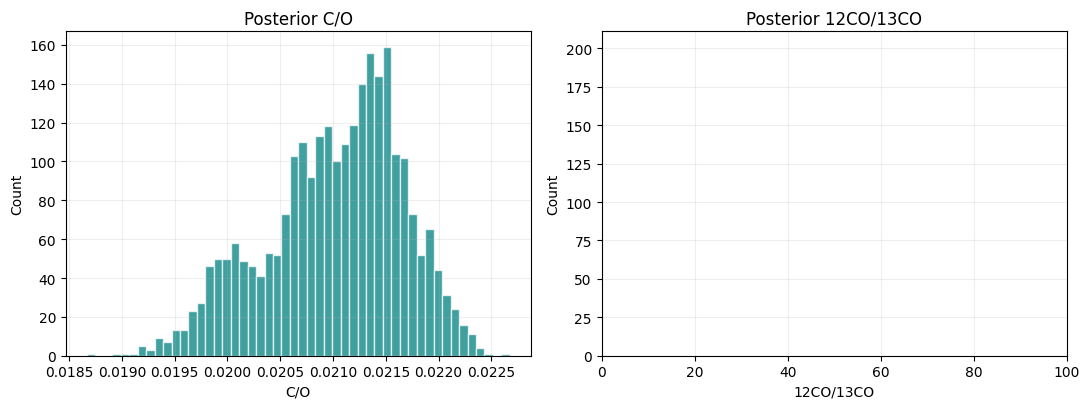

In [6]:
# ------------------------------------------------------------------
# 2) Chemistry diagnostics workflow
# ------------------------------------------------------------------
chem_out = run_chemistry_workflow(workpath=workpath, retrieval_id=retrieval_id)

print('Posterior shape:', chem_out['posterior'].shape)
print('Posterior columns:', chem_out['columns'])
display(chem_out['summary'])

print('\nText summary:')
for _, row in chem_out['summary'].iterrows():
    print(
        f"{row['parameter']}: median={row['p50']:.4g}, "
        f"1σ=[-{row['minus_1sigma']:.3g}, +{row['plus_1sigma']:.3g}], "
        f"3σ=[-{row['minus_3sigma']:.3g}, +{row['plus_3sigma']:.3g}]"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(chem_out['co_ratio_samples'][np.isfinite(chem_out['co_ratio_samples'])],
             bins=50, color='teal', alpha=0.75, edgecolor='white')
axes[0].set_title('Posterior C/O')
axes[0].set_xlabel('C/O')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.2)

axes[1].hist(chem_out['c12_c13_samples'][np.isfinite(chem_out['c12_c13_samples'])],
             bins=50, color='indigo', alpha=0.75, edgecolor='white')
axes[1].set_xlim(0,100)

axes[1].set_title('Posterior 12CO/13CO')
axes[1].set_xlabel('12CO/13CO')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()